# Predict logP

The aim of this exercise is to compare model performance between a GNN and a supervised method to predict logP. 
Consider as a starting point one of the GNNs from session 14 (GCN, GIN, or GAT), and a supervised model of your choice (e.g., Random Forest with MACCS fingerprints).

#### Tasks:
1) Create a training and a test set
2) Build a supervised model of your choice on the training data and evaluate its performance on the test set
3) Build a GNN and compare its performance to the supervised model
4) Discuss the outcome


In [1]:
# complete imports if needed for your solution
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


Load the data from Session 11

In [2]:
df = pd.read_csv(os.path.join("..", "lectures", "session11", "material", "esol_modified.csv")).dropna(subset=["SMILES"])
df = df.loc[df.SMILES != 'C'] # remove the one compound containing only a single atom
df.head()

,SMILES,LogS,MolWt,LogP,EState_VSA5,TPSA,NumHAcc,NumAromaticRings,HeavyAtomCount,RingCount,qed,NumHDonors,NOCount
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,0.000000,202.32,12.0,1.0,32.0,3.0,0.217518,7.0,12.0
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,6.263163,42.24,2.0,2.0,15.0,2.0,0.811283,1.0,3.0
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,5.573105,17.07,1.0,0.0,11.0,0.0,0.343706,0.0,1.0
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,43.089794,0.00,0.0,5.0,22.0,5.0,0.291526,0.0,0.0
4,c1ccsc1,-1.33,84.143,1.74810,0.000000,0.00,1.0,1.0,5.0,1.0,0.448927,0.0,0.0


In [3]:
df.describe()

,LogS,MolWt,LogP,EState_VSA5,TPSA,NumHAcc,NumAromaticRings,HeavyAtomCount,RingCount,qed,NumHDonors,NOCount
count,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000
mean,-3.052010,204.103795,2.449127,9.974406,34.903824,2.113576,0.931677,13.300799,1.392192,0.553054,0.701863,2.429459
std,2.096392,102.630917,1.852911,13.915174,35.384029,2.153411,1.005199,6.871895,1.318219,0.149158,1.090010,2.421804
min,-11.600000,26.038000,-7.571400,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.146432,0.000000,0.000000
25%,-4.321000,121.651500,1.414900,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.451039,0.000000,0.000000
50%,-2.860000,182.179000,2.339200,6.066367,26.300000,2.000000,1.000000,12.000000,1.000000,0.533979,0.000000,2.000000
75%,-1.600000,270.372000,3.402200,13.940505,55.480000,3.000000,2.000000,18.000000,2.000000,0.648945,1.000000,4.000000
max,1.580000,780.949000,10.388600,154.099719,268.680000,16.000000,7.000000,55.000000,8.000000,0.934235,11.000000,16.000000


In [4]:
df_X = df.drop(columns=["LogP","SMILES"])
df_y = df["LogP"]

### Setting the stage
Split the data into training and test sets. The test set will be used to compare model performance.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(df_X,df_y, test_size=0.2, random_state=42)

### Baseline supervised model
Choose a 
   - regression model (RF, SVR, kNN, Gradient Boost, ...) 
   - molecular descriptor (RDKit, Mordred, ...) or fingerprint (MACCS, Morgan, RDKit, ...)
      
Build a feature matrix and target vector. Add scaling if needed for your model.
Train the model on the training set and apply it to the test set.
Calculate performance metrics (R2, RMSE) for model performance on the test set.

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
model_RF = RandomForestRegressor()


grid_RF_params = {
    "max_depth" : [200,500,None],
    "min_samples_split": [2,3,4],
    "min_samples_leaf": [1,2],
    "n_estimators": [50, 100],
    "max_features": ["sqrt", "log2"]

    }

grid_RF = GridSearchCV(
    model_RF,
    grid_RF_params,
    scoring="r2"
)

grid_RF.fit(X_train,y_train)

print(f"best parameters: {grid_RF.best_params_}, best score: {grid_RF.best_score_}")


best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}, best score: 0.9280267583485436


In [7]:
final_RF_model = RandomForestRegressor(**grid_RF.best_params_)
final_RF_model.fit(X_train,y_train)
y_pred_RF = final_RF_model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score

mse_RF = mean_squared_error(y_test, y_pred_RF)
r2_RF = r2_score(y_test, y_pred_RF)
print(f"mean squared error for RF: {mse_RF}")
print(f"R2 score for RF: {r2_RF}")

mean squared error for RF: 0.3181933217737965
R2 score for RF: 0.9120262493384149


### Unpervised GNN model
Choose a GNN architecture
   - GCN, GIN, or GAT
      
Transform input smiles to graph objects using the atom and bond features. Build graphs for both training and test set. Train the GNN on the training set. Adapt architecture and parameters until you are happy with the performance. Apply the trained model on the test set (once!) and calculate model performance metrics

In [8]:
import torch
import torch_geometric
from rdkit import Chem
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader


In [9]:
mol_objects = []

for i in df["SMILES"]:
    mol = Chem.MolFromSmiles(i)
    mol_objects.append(mol)
df["Mol_Obj"] = mol_objects

In [10]:
df_gnn = df[["Mol_Obj","LogP"]]



In [11]:
def mol_to_graph(mol, y):

    atom_features = []

    for atom in mol.GetAtoms():

        features = [
            atom.GetAtomicNum(),
            atom.GetDegree(),
            atom.GetFormalCharge(),
            atom.GetTotalNumHs(),
            int(atom.GetIsAromatic()),
            int(atom.IsInRing())
        ]

        atom_features.append(features)


    edge_index = []
    bond_features = []

    for bond in mol.GetBonds():

        start = bond.GetBeginAtomIdx()
        end = bond.GetEndAtomIdx()

        edge_index.append([start, end])
        edge_index.append([end, start])

        features = [
            bond.GetBondTypeAsDouble(),
            int(bond.GetIsConjugated()),
            int(bond.IsInRing()),
            int(bond.GetIsAromatic())
        ]

        bond_features.append(features)
        bond_features.append(features)


    x = torch.tensor(atom_features, dtype=torch.float)
    edge_index = torch.tensor(edge_index, dtype=torch.long).t()
    edge_attr = torch.tensor(bond_features, dtype=torch.float)
    y = torch.tensor([y], dtype=torch.float)

    graph = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

    return graph

In [12]:
graph_list = []

for i,row in df_gnn.iterrows():

    mol = row["Mol_Obj"]
    target = row["LogP"]

    graph = mol_to_graph(mol, target)

    graph_list.append(graph)

In [13]:
graph_list[0]

Data(x=[32, 6], edge_index=[2, 68], edge_attr=[68, 4], y=[1])

In [14]:
train_graphs, test_graphs = train_test_split(graph_list, test_size=0.2, random_state=42)

In [15]:
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

In [16]:
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn as nn
import torch.nn.functional as F

class GCN(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.conv1 = GCNConv(in_channels, 32)
        self.conv2 = GCNConv(32, 64)
        self.conv3 = GCNConv(64, 64)

        self.lin1 = nn.Linear(64, 32)
        self.lin2 = nn.Linear(32, 1)

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        batch = data.batch

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)

        x = self.lin1(x)
        x = F.relu(x)

        x = self.lin2(x)


        return x

In [46]:
model = GCN(in_channels=6)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.MSELoss()

In [47]:
def train():
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        out = model(batch).squeeze()
        loss = criterion(out, batch.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [48]:
def test(loader):
    model.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for batch in loader:
            out = model(batch).squeeze()

            preds.extend(out.cpu().numpy())
            targets.extend(batch.y.cpu().numpy())

    mse = mean_squared_error(targets, preds)
    r2 = r2_score(targets, preds)

    return mse, r2

In [49]:
train_losses = []
test_mse_list = []
test_r2_list = []

num_epochs = 2000

for epoch in range(num_epochs):
    loss = train()
    test_mse, test_r2 = test(test_loader)

    train_losses.append(loss)
    test_mse_list.append(test_mse)
    test_r2_list.append(test_r2)
    if epoch % 100 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {loss:.4f} | Test MSE: {test_mse:.4f} | Test R2: {test_r2:.4f}")

Epoch 001 | Train Loss: 7.3935 | Test MSE: 5.4744 | Test R2: -0.5136
Epoch 101 | Train Loss: 1.1895 | Test MSE: 1.1986 | Test R2: 0.6686
Epoch 201 | Train Loss: 0.9839 | Test MSE: 1.1187 | Test R2: 0.6907
Epoch 301 | Train Loss: 0.8816 | Test MSE: 1.1555 | Test R2: 0.6805
Epoch 401 | Train Loss: 0.7815 | Test MSE: 0.8468 | Test R2: 0.7659
Epoch 501 | Train Loss: 0.7380 | Test MSE: 0.8062 | Test R2: 0.7771
Epoch 601 | Train Loss: 0.5644 | Test MSE: 0.7601 | Test R2: 0.7898
Epoch 701 | Train Loss: 0.6479 | Test MSE: 0.7861 | Test R2: 0.7827
Epoch 801 | Train Loss: 0.4583 | Test MSE: 0.7004 | Test R2: 0.8064
Epoch 901 | Train Loss: 0.4672 | Test MSE: 0.8169 | Test R2: 0.7741
Epoch 1001 | Train Loss: 0.3947 | Test MSE: 0.7338 | Test R2: 0.7971
Epoch 1101 | Train Loss: 0.4580 | Test MSE: 0.6268 | Test R2: 0.8267
Epoch 1201 | Train Loss: 0.3296 | Test MSE: 0.5536 | Test R2: 0.8469
Epoch 1301 | Train Loss: 0.3147 | Test MSE: 0.5469 | Test R2: 0.8488
Epoch 1401 | Train Loss: 0.3409 | Test MSE:

In [50]:
final_mse, final_r2 = test(test_loader)

print("Final Test MSE:", final_mse)
print("Final Test R2:", final_r2)

Final Test MSE: 0.4334290362239853
Final Test R2: 0.8801660029315428


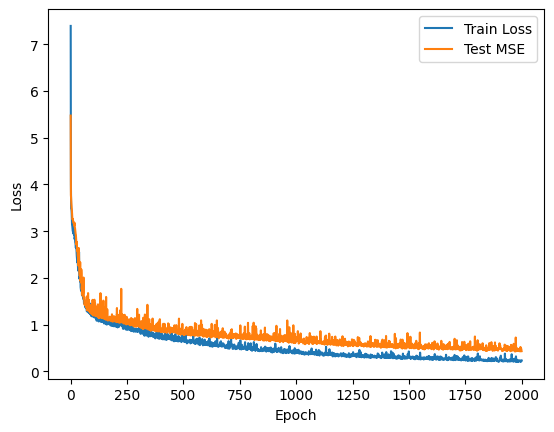

In [51]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(train_losses, label="Train Loss")
plt.plot(test_mse_list, label="Test MSE")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


### Discussion points
1) Which model (supervised or unsupervised) performed better on the test set, and why?
2) What did you try to improve model performance of your GNN? What did work, what did not work?
3) Which challenges did you face in the process of building the models?
4) Which of your two models would you recommend to a chemist for predicting logP, and why?

1. The RF performed better on the test set than the GNN. A likely reason is that the dataset is quite small which makes supervised models often perform better
2. To improve the GNN, I varied the model size as well as learning rate and epochs.
3. The RF model was quite easy to build from the data we received but the GNN was a lot more complex because we had to use DataLoaders and convert to tensors as well as use the Mol Object from RDKit and thus not being able to just directly use the tabular data.
4. I believe that in a research setting, where a lot more data is available, the GNN would be a better strategy but for quick analysis where background values (like we had from the session 11 csv file) are known, the RF is easier to use. But starting from a SMILES and getting a similar performance to the RF using a small dataset seems very promising.